<a href="https://colab.research.google.com/github/remonrefaat18-a11y/ML_project1/blob/main/svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

In [5]:
#Read Dataset Files
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

X=pd.read_csv("../data/X.csv")
y=pd.read_csv("../data/y.csv").squeeze()

In [6]:
#Explore the Dataset
X.head()

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (19368, 8)
y Shape: (19368,)


In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19368 entries, 0 to 19367
Data columns (total 8 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Total Bilirubin                       19368 non-null  float64
 1   Direct Bilirubin                      19368 non-null  float64
 2   Alkphos Alkaline Phosphotase          19368 non-null  float64
 3   Sgpt Alamine Aminotransferase         19368 non-null  float64
 4   Sgot Aspartate Aminotransferase       19368 non-null  float64
 5   Total Protiens                        19368 non-null  float64
 6   ALB Albumin                           19368 non-null  float64
 7   A/G Ratio Albumin and Globulin Ratio  19368 non-null  float64
dtypes: float64(8)
memory usage: 1.2 MB


In [8]:
X.describe()

,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio
count,19368.000000,19368.000000,19368.000000,19368.000000,19368.000000,19368.000000,19368.000000,19368.000000
mean,3.249169,1.484882,286.490397,79.518123,109.394827,6.496344,3.140169,0.945530
std,6.035743,2.833589,235.878731,179.109663,276.253721,1.079620,0.785117,0.318386
min,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000
25%,0.800000,0.200000,177.000000,23.000000,26.000000,5.800000,2.600000,0.700000
50%,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000
75%,2.600000,1.200000,293.000000,60.000000,87.000000,7.200000,3.800000,1.100000
max,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000


In [9]:
X.isnull().sum()

Total Bilirubin                         0
Direct Bilirubin                        0
Alkphos Alkaline Phosphotase            0
Sgpt Alamine Aminotransferase           0
Sgot Aspartate Aminotransferase         0
Total Protiens                          0
ALB Albumin                             0
A/G Ratio Albumin and Globulin Ratio    0
dtype: int64

In [10]:
y.value_counts()

Result
1    13811
0     5557
Name: count, dtype: int64

In [11]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
#Create the SVM Model
svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

In [13]:
#Train the Model
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [14]:
#Training & Testing Accuracy
y_train_pred = svm_model.predict(X_train_scaled)
y_test_pred = svm_model.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy : {test_acc:.4f}")

Training Accuracy: 0.7358
Testing Accuracy : 0.7370


In [15]:
#Predictions
y_pred = svm_model.predict(X_test_scaled)

y_prob = svm_model.predict_proba(X_test_scaled)[:,1]

In [16]:
#Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

In [17]:
#Print Metrics
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.7370
Precision: 0.7403
Recall   : 0.9721
F1 Score : 0.8405
ROC AUC  : 0.8098


In [18]:
#Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.15      0.25      1112
           1       0.74      0.97      0.84      2762

    accuracy                           0.74      3874
   macro avg       0.71      0.56      0.55      3874
weighted avg       0.73      0.74      0.67      3874



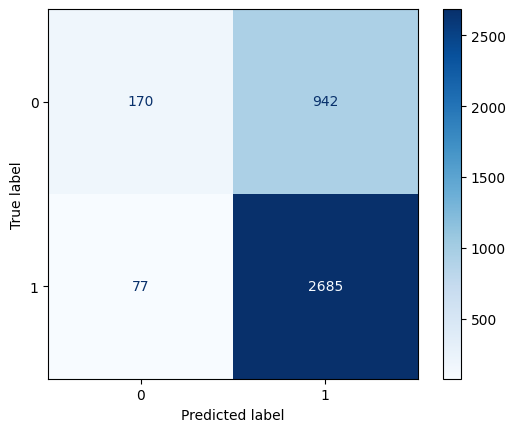

In [19]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Blues")

plt.show()

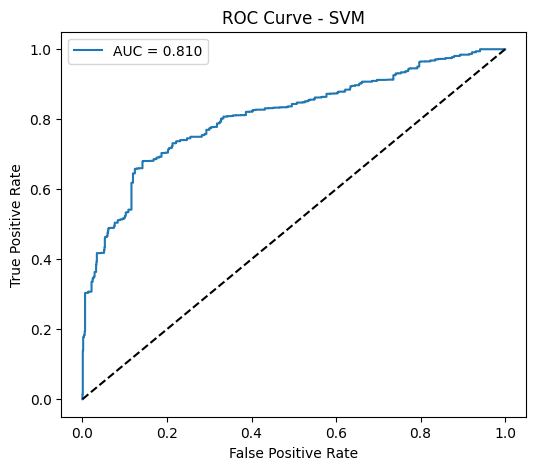

In [20]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()

plt.show()

In [21]:
#Save Results in DataFrame
results = pd.DataFrame({

    "Model":["SVM"],
    "Accuracy":[accuracy],
    "Precision":[precision],
    "Recall":[recall],
    "F1 Score":[f1],
    "ROC AUC":[roc_auc]

})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,SVM,0.736964,0.740281,0.972122,0.840507,0.809789


In [22]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "svm_classification_report.csv"
)

Training Accuracy: 0.7358
Testing Accuracy : 0.7370
Accuracy : 0.7370
Precision: 0.7403
Recall   : 0.9721
F1 Score : 0.8405
ROC AUC  : 0.8098

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.15      0.25      1112
           1       0.74      0.97      0.84      2762

    accuracy                           0.74      3874
   macro avg       0.71      0.56      0.55      3874
weighted avg       0.73      0.74      0.67      3874



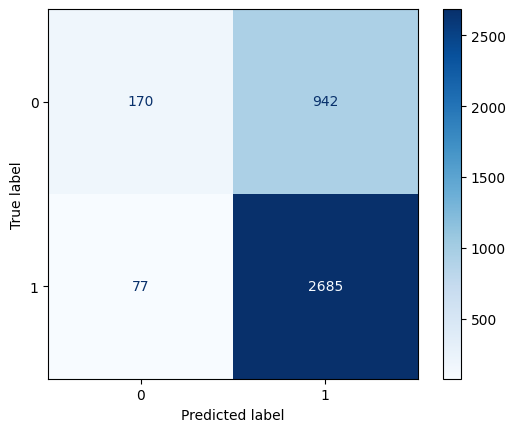

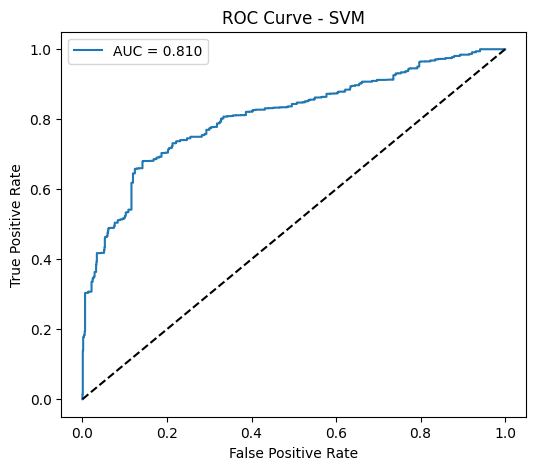

In [23]:
from sklearn.metrics import accuracy_score

y_train_pred = svm_model.predict(X_train_scaled)
y_test_pred = svm_model.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy : {test_acc:.4f}")


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

import matplotlib.pyplot as plt


y_pred = svm_model.predict(X_test_scaled)

y_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.show()


fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()


results = pd.DataFrame({
    "Model": ["SVM"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC AUC": [roc_auc]
})



results.to_csv("../results/svm_results.csv", index=False)


report = classification_report(y_test, y_pred, output_dict=True)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "../results/svm_classification_report.csv"
)
